In [1]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300
import stylia
import pandas as pd
import numpy as np
import os

In [2]:
pathogens = np.array([
    "Acinetobacter baumannii", "Candida albicans", "Campylobacter", "Escherichia coli",
    "Enterococcus faecium", "Enterobacter", "Helicobacter pylori", "Klebsiella pneumoniae",
    "Mycobacterium tuberculosis", "Neisseria gonorrhoeae", "Pseudomonas aeruginosa",
    "Plasmodium falciparum", "Staphylococcus aureus", "Schistosoma mansoni", "Streptococcus pneumoniae"
])

def get_pathogen_code(pathogen):
    return str(pathogen.split()[0][0] + pathogen.split()[1]).lower() if len(pathogen.split()) > 1 else pathogen.lower()

PATH_TO_OUTPUT = os.path.join(".", "..", "output")

In [3]:
RESULTS = {}
for pathogen in pathogens:
    pathogen_code = get_pathogen_code(pathogen)
    chembl = pd.read_csv(os.path.join(PATH_TO_OUTPUT, pathogen_code, "08_chembl_cleaned_data.csv.gz"), low_memory=False)
    assays = pd.read_csv(os.path.join(PATH_TO_OUTPUT, pathogen_code, "08_assays_cleaned.csv"))
    RESULTS[pathogen_code] = {
        "compounds": len(set(chembl["compound_chembl_id"])),
        "activities": len(chembl),
        "assays": len(assays),
        "assays_100": len(assays[assays["cpds"] >= 100]),
        "assays_1000": len(assays[assays["cpds"] >= 1000]),
        "assays_10000": len(assays[assays["cpds"] >= 10000]),
    }
    print(f"{pathogen_code}: {RESULTS[pathogen_code]}")

abaumannii: {'compounds': 32513, 'activities': 42894, 'assays': 3008, 'assays_100': 4, 'assays_1000': 3, 'assays_10000': 1}
calbicans: {'compounds': 42845, 'activities': 81774, 'assays': 11202, 'assays_100': 17, 'assays_1000': 3, 'assays_10000': 0}
campylobacter: {'compounds': 684, 'activities': 1914, 'assays': 434, 'assays_100': 0, 'assays_1000': 0, 'assays_10000': 0}
ecoli: {'compounds': 152644, 'activities': 258578, 'assays': 21741, 'assays_100': 53, 'assays_1000': 6, 'assays_10000': 1}
efaecium: {'compounds': 7877, 'activities': 14199, 'assays': 1899, 'assays_100': 1, 'assays_1000': 0, 'assays_10000': 0}
enterobacter: {'compounds': 5537, 'activities': 10699, 'assays': 1736, 'assays_100': 2, 'assays_1000': 0, 'assays_10000': 0}
hpylori: {'compounds': 1683, 'activities': 4143, 'assays': 699, 'assays_100': 0, 'assays_1000': 0, 'assays_10000': 0}
kpneumoniae: {'compounds': 26079, 'activities': 45620, 'assays': 5472, 'assays_100': 3, 'assays_1000': 1, 'assays_10000': 0}
mtuberculosis: {

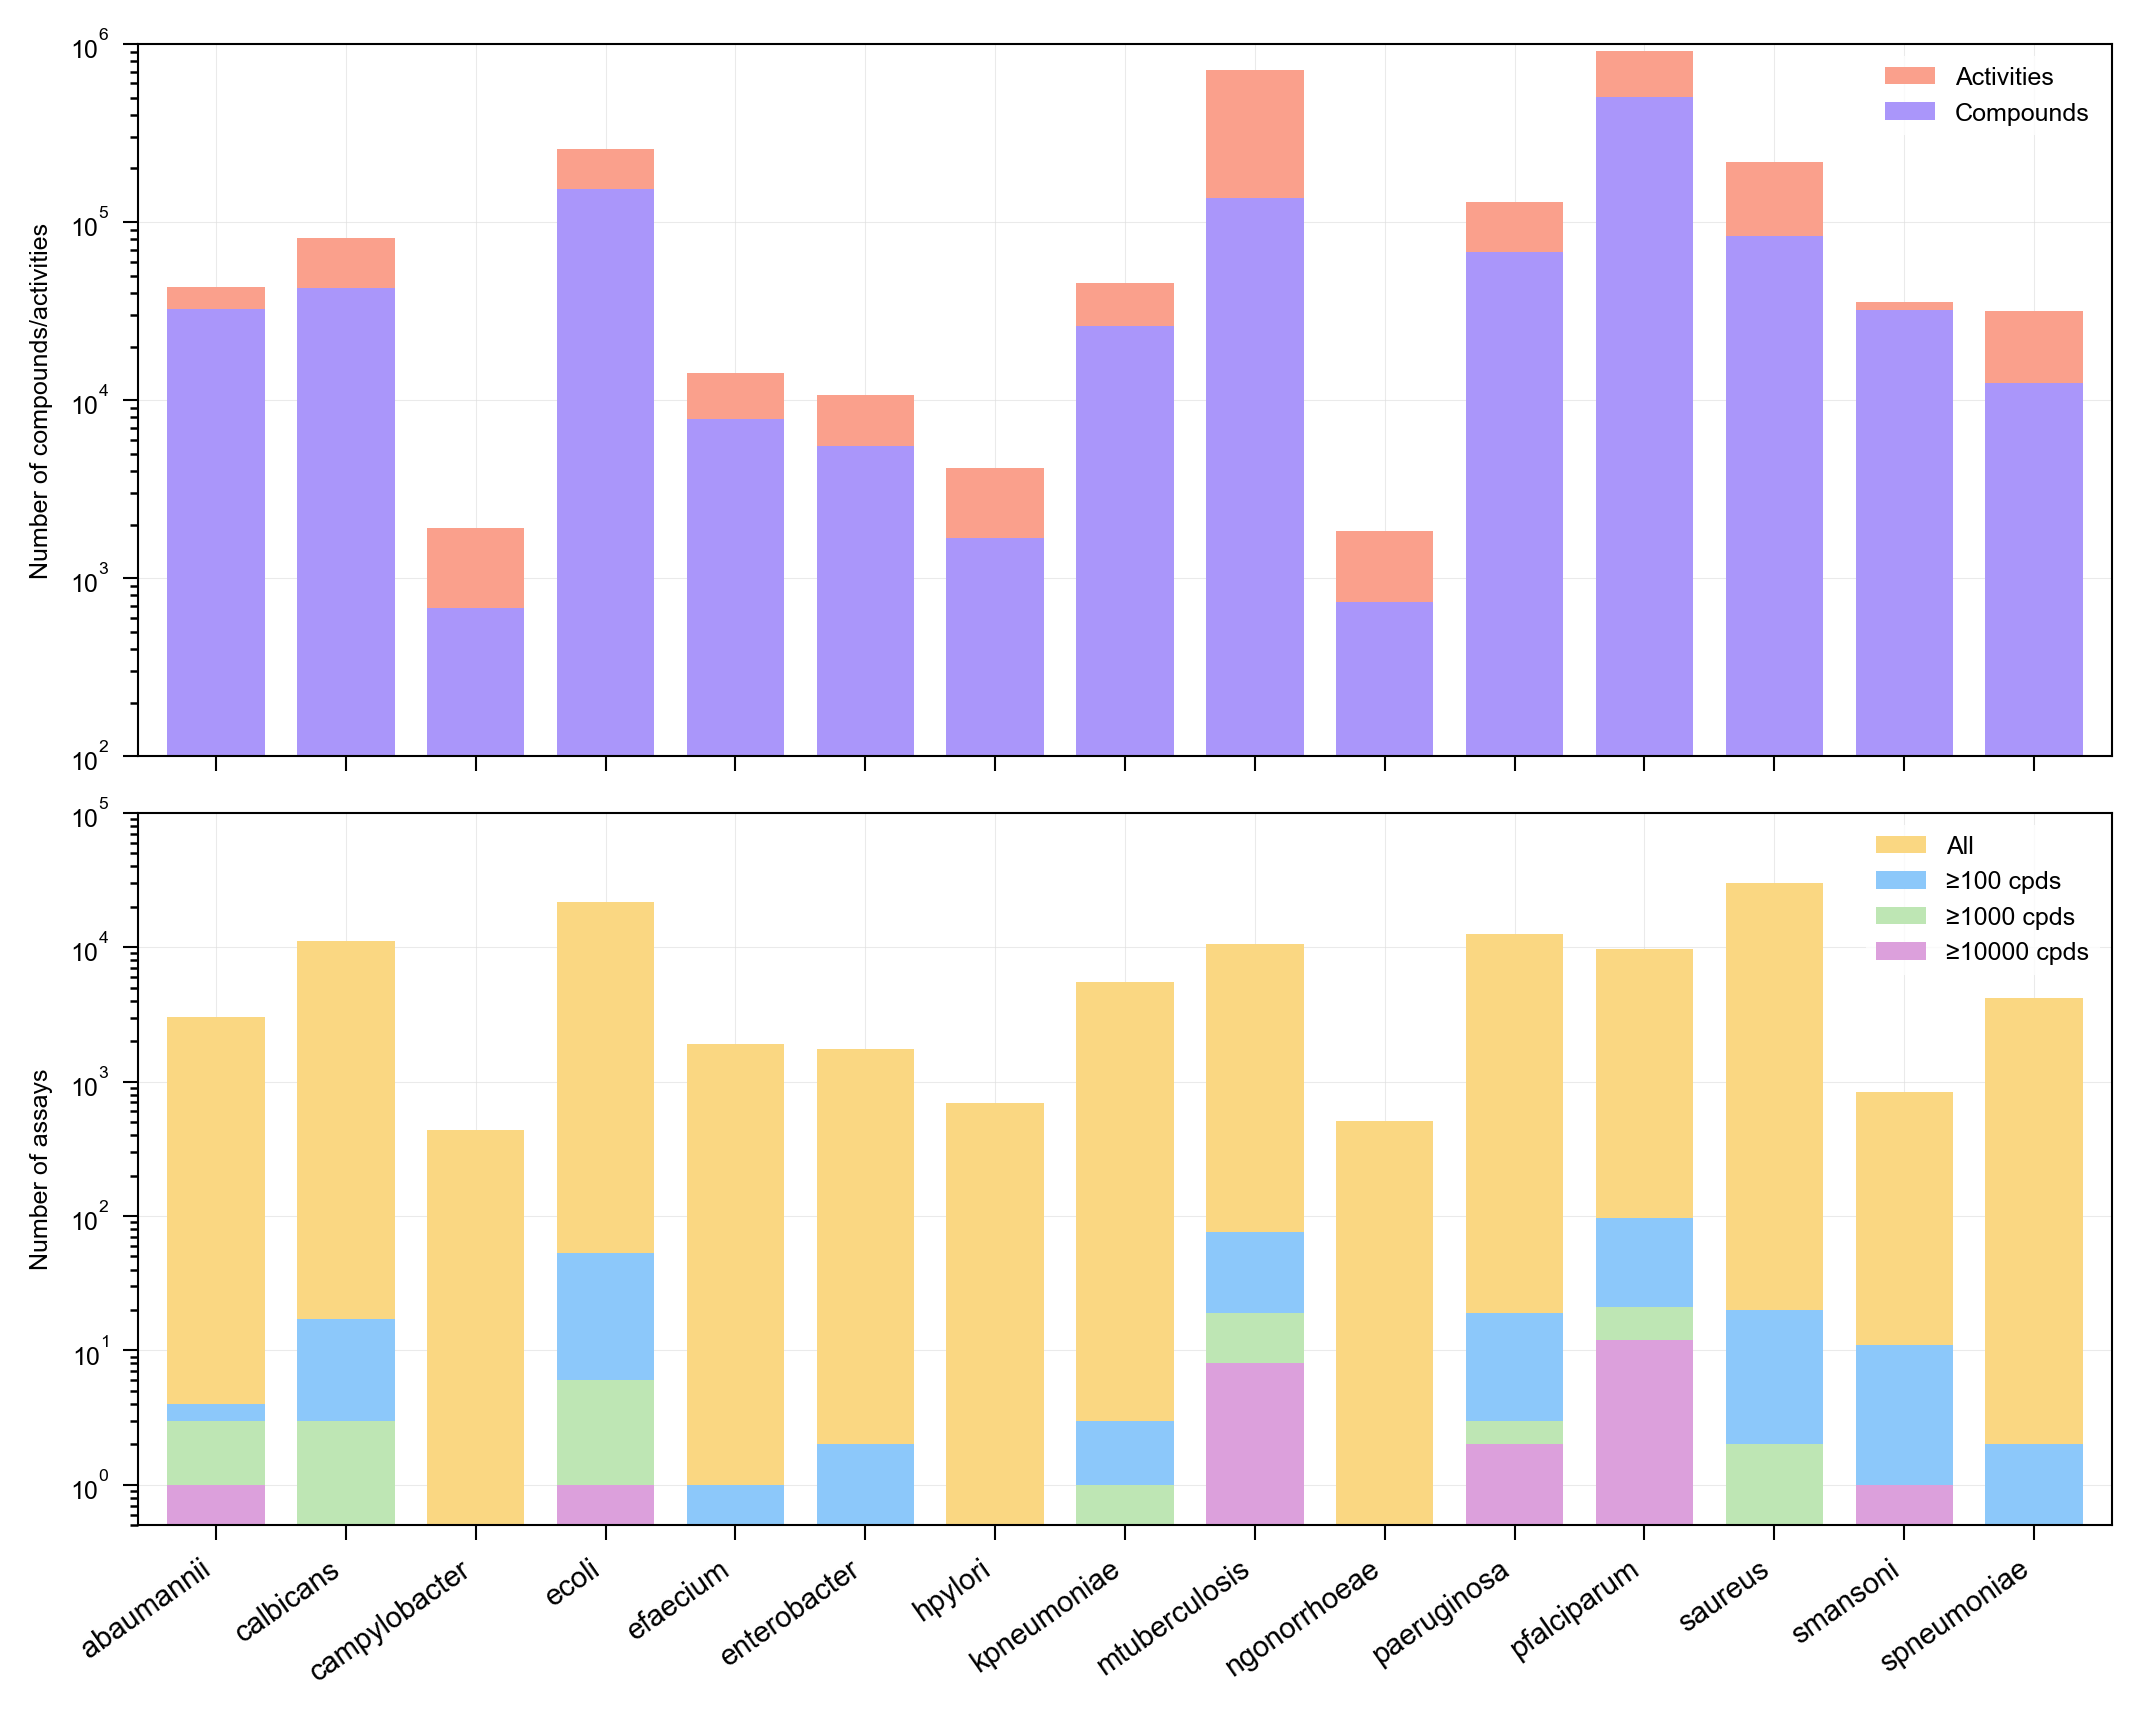

In [12]:
ec = stylia.ErsiliaColors()
codes = sorted(RESULTS.keys())
x = np.arange(len(codes))
w = 0.75  # individual bar width for grouped bars

fig, axs = stylia.create_figure(2, 1, width=1.0, height=0.8)

# --- Top: compounds and activities ---
ax = axs.next()
ax.bar(x, [RESULTS[c]["activities"] for c in codes], width=w, color=ec.orange, zorder=2, label="Activities")
ax.bar(x, [RESULTS[c]["compounds"] for c in codes], width=w, color=ec.purple, zorder=2, label="Compounds")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_xlabel("")
ax.legend()
ax.set_xlim([-0.6, len(x) - 0.4])
ax.set_ylim([10**2, 10**6])
stylia.label(ax, ylabel="Number of compounds/activities")

# --- Bottom: all assays, ≥100 cpds, ≥1000 cpds ---
ax = axs.next()
ax.bar(x, [RESULTS[c]["assays"] for c in codes], width=w, color=ec.yellow, zorder=2, label="All")
ax.bar(x, [RESULTS[c]["assays_100"] for c in codes], width=w, color=ec.blue, zorder=2, label="\u2265100 cpds")
ax.bar(x, [RESULTS[c]["assays_1000"] for c in codes], width=w, color=ec.mint, zorder=2, label="\u22651000 cpds")
ax.bar(x, [RESULTS[c]["assays_10000"] for c in codes], width=w, color=ec.pink, zorder=2, label="\u226510000 cpds")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(codes, rotation=35, ha="right", size=7)
ax.set_xlabel("")
ax.legend()
ax.set_xlim([-0.6, len(x) - 0.4])
ax.set_ylim([0.5, 10**5])
stylia.label(ax, ylabel="Number of assays")